In [1]:
from functools import partial
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
# BAYESFLOW
import bayesflow.diagnostics as diag
from bayesflow.amortizers import AmortizedPosterior
from bayesflow.networks import InvertibleNetwork
from bayesflow.simulation import GenerativeModel, Prior, Simulator
from bayesflow.trainers import Trainer
# TENSDORFLOW
from tensorflow.keras.layers import ConvLSTM2D, BatchNormalization, Conv2D, MaxPooling2D, TimeDistributed, Flatten, Dense
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels as sm
import statsmodels.api as sm
import copy
from scipy.spatial.distance import pdist, squareform
from scipy.stats import mvn, gamma as xgamma, norm,multivariate_normal
from scipy.special import gamma, factorial
from timeit import default_timer as timer
from sklearn.preprocessing import MinMaxScaler
from datetime import datetime

rng = np.random.default_rng(123)

# Configuración para permitir el uso de toda la GPU disponible
physical_devices = tf.config.list_physical_devices('GPU')
if len(physical_devices) > 0:
    # Hacer visibles todas las GPUs disponibles
    tf.config.set_visible_devices(physical_devices, 'GPU')
    print(f"Se detectaron {len(physical_devices)} GPU(s) y se han configurado para su uso.")
    # Configurar para permitir el crecimiento dinámico de la memoria de cada GPU
    for device in physical_devices:
        tf.config.experimental.set_memory_growth(device, True)
else:
    print("No se detectaron GPUs.")


C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\bayesflow\trainers.py:27: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


No se detectaron GPUs.


In [2]:
import numpy as np
import pandas as pd

n_sitios = 10
n_obs = 120

# Coordenadas de cada sitio
lon_sitios = rng.uniform(-1, -0.5, size=n_sitios)
lat_sitios = rng.uniform(0.5, 1, size=n_sitios)

# Variables por sitio
dummy = rng.integers(0, 2, size=n_sitios)

# Matriz de covariables espaciales
X = pd.DataFrame({
    "intercepto": np.ones(n_sitios),
    "dummy": dummy,
    "lon": lon_sitios,
    "lat": lat_sitios,
})

# Betas espaciales verdaderos
beta = np.array([3, 0.2, -0.05, 0.05, 2])

# Efecto espacial de cada sitio
# Resultado: (10,)
efecto_espacial = X.values @ beta[0:4]

# Efecto temporal común
oscilacion_base = np.sin(np.linspace(0, 2*np.pi, n_obs))

# Efecto temporal + espacial
# Broadcasting:
elevar = oscilacion_base[:, None] * np.array(beta[4:5]) + efecto_espacial[None, :]

# Datos sintéticos
Y = np.exp(elevar)# + rng.normal(0, 0.1, size=(n_obs, n_sitios))

print("X:", X.shape)
print("Y:", Y.shape)

X: (10, 4)
Y: (120, 10)


In [3]:
pd.DataFrame(Y).describe()

,0,1,2,3,4,5,6,7,8,9
count,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000
mean,59.744094,49.357190,49.869117,49.158002,49.821364,48.898710,49.126884,59.930659,49.096568,48.667511
std,65.135485,53.811253,54.369377,53.594090,54.317315,53.311399,53.560164,65.338887,53.527112,53.059336
min,3.564200,2.944541,2.975081,2.932658,2.972232,2.917189,2.930801,3.575330,2.928992,2.903396
25%,6.524506,5.390178,5.446084,5.368425,5.440869,5.340108,5.365027,6.544881,5.361716,5.314860
50%,26.331487,21.753585,21.979211,21.665796,21.958164,21.551516,21.652081,26.413714,21.638719,21.449617
75%,106.296295,87.815986,88.726802,87.461591,88.641841,87.000260,87.406226,106.628231,87.352288,86.588912
max,194.530941,160.710459,162.377327,160.061888,162.221842,159.217614,159.960566,195.138411,159.861854,158.464814


In [4]:
def model_prior():
    # betas = rng.uniform(low=-10, high=10, size=(n_sim, n_betas))
    betas = rng.normal(loc=0, scale=5, size=(5))
    return betas

parametros= [ r"$\beta_0$", r"$\beta_1$",r"$\beta_2$", r"$\beta_3$",r"$\beta_4$"]
prior = Prior(prior_fun=model_prior, param_names=parametros)
prior_means, prior_stds = prior.estimate_means_and_stds()
print("Medias del prior:", prior_means)

Medias del prior: [[ 0.1472155   0.07470861 -0.07073237 -0.30429582  0.25877435]]


In [5]:
def proceso_D8(params):
    
    # Efecto espacial de cada sitio
    # Resultado: (10,)
    efecto_espacial = X.values @ params[0:4]

    # Efecto temporal común
    oscilacion_base = np.sin(np.linspace(0, 2*np.pi, n_obs))

    # Efecto temporal + espacial
    # Broadcasting:
    elevar = oscilacion_base[:, None] * np.array(params[4:5]) + efecto_espacial[None, :]

    # Datos sintéticos
    Y = np.exp(elevar)# + rng.normal(0, 0.1, size=(n_obs, n_sitios))
    return(Y)
simulator_D8 = Simulator(simulator_fun=partial(proceso_D8))
model_D8 = GenerativeModel(prior, simulator_D8, name="simulador_proceso")
data_D8 = model_D8(batch_size=1)

print('Inicia simulacion')
myobj=datetime.now()
print(myobj)
simul_previa_D8 = model_D8(batch_size=50000)
print('Termina simulacion')
myobj=datetime.now()
print(myobj)


INFO:root:Performing 2 pilot runs with the simulador_proceso model...
INFO:root:Shape of parameter batch after 2 pilot simulations: (batch_size = 2, 5)
INFO:root:Shape of simulation batch after 2 pilot simulations: (batch_size = 2, 120, 10)
INFO:root:No optional prior non-batchable context provided.
INFO:root:No optional prior batchable context provided.
INFO:root:No optional simulation non-batchable context provided.
INFO:root:No optional simulation batchable context provided.


Inicia simulacion
2026-07-07 08:37:27.565146
Termina simulacion
2026-07-07 08:37:30.922727


In [8]:
class CustomLSTM_D8(tf.keras.Model):
    def __init__(self, hidden_size=512, summary_dim=512):
        super().__init__()
        timesteps = n_obs
        features = n_sitios
        self.LSTM = tf.keras.Sequential(
            [   tf.keras.layers.Input((timesteps, features)),
                tf.keras.layers.LSTM(hidden_size, return_sequences=True),
                tf.keras.layers.LSTM(hidden_size, return_sequences=False),
 #               tf.keras.layers.Flatten(),
                tf.keras.layers.Dense(hidden_size, activation="relu"),
                tf.keras.layers.Dense(summary_dim, activation="elu"),
            ]
        )
 
    def call(self, x, **kwargs):
        x = tf.reshape(x, (-1, n_obs, n_sitios))  # Ajusta según sea necesario
        out = self.LSTM(x)
        return out

In [9]:

COUPLING_NET_SETTINGS = {
    # "dense_args": dict(units=128, kernel_regularizer=None, activation="relu"),
    "num_dense": 2,
    "dropout_prob": 0.2, "bins" : 32
}
# SUBIR a 1024, 1024
summary_net_D8 = CustomLSTM_D8(hidden_size=128, summary_dim=128)
inference_net_D8 = InvertibleNetwork(num_params=5, num_coupling_layers=4, coupling_settings=COUPLING_NET_SETTINGS,coupling_design='spline')
amortizer_D8 = AmortizedPosterior(inference_net_D8, summary_net_D8)
trainer_D8 = Trainer(amortizer=amortizer_D8, generative_model=model_D8, memory=False)


myobj= datetime.now()
print(myobj)



INFO:root:Performing a consistency check with provided components...
INFO:root:Done.


2026-07-07 08:40:30.841269


INFO:root:Generated 128 simulations for validation.
Training epoch 1: 100%|██████████| 391/391 [02:42<00:00,  2.41it/s, Epoch: 1, Batch: 391,Loss: 12.568,W.Decay: 0.201,Avg.Loss: 14.201,Avg.W.Decay: 0.203,LR: 4.97E-04]
INFO:root:Validation, Epoch: 1, Loss: 11.336
Training epoch 2: 100%|██████████| 391/391 [01:56<00:00,  3.37it/s, Epoch: 2, Batch: 391,Loss: 10.715,W.Decay: 0.200,Avg.Loss: 10.987,Avg.W.Decay: 0.200,LR: 4.88E-04]
INFO:root:Validation, Epoch: 2, Loss: 10.121
Training epoch 3: 100%|██████████| 391/391 [02:04<00:00,  3.15it/s, Epoch: 3, Batch: 391,Loss: 9.045,W.Decay: 0.199,Avg.Loss: 10.158,Avg.W.Decay: 0.199,LR: 4.73E-04] 
INFO:root:Validation, Epoch: 3, Loss: 9.846
Training epoch 4: 100%|██████████| 391/391 [01:57<00:00,  3.32it/s, Epoch: 4, Batch: 391,Loss: 9.506,W.Decay: 0.198,Avg.Loss: 9.632,Avg.W.Decay: 0.198,LR: 4.52E-04] 
INFO:root:Validation, Epoch: 4, Loss: 8.996
Training epoch 5: 100%|██████████| 391/391 [02:01<00:00,  3.22it/s, Epoch: 5, Batch: 391,Loss: 7.838,W.

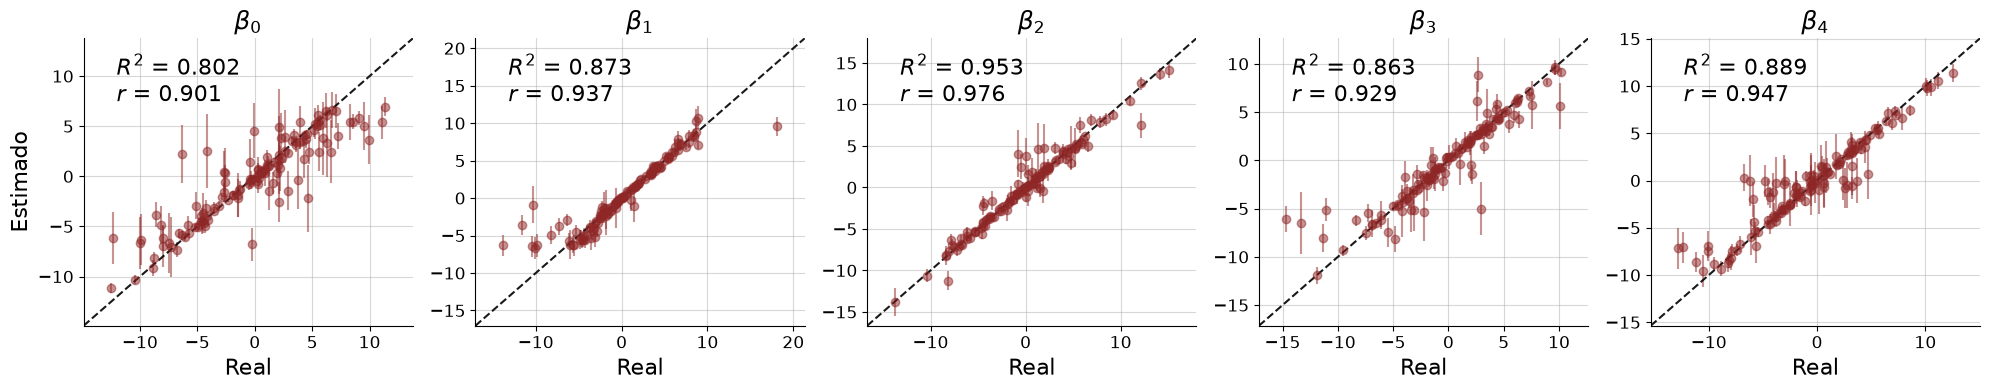

In [10]:
n_epochs = 20
n_batch_size = 128


history_D8 = trainer_D8.train_offline(simulations_dict=simul_previa_D8,epochs=n_epochs,batch_size=n_batch_size,early_stopping=True,validation_sims=128)
valid_sim_data_raw_D8 = model_D8(batch_size=128)
valid_sim_data_D8 = trainer_D8.configurator(valid_sim_data_raw_D8)
posterior_samples_D8 = amortizer_D8.sample(valid_sim_data_D8, n_samples=100)
fig = diag.plot_recovery(posterior_samples_D8, valid_sim_data_D8["parameters"], param_names=parametros, xlabel= "Real",ylabel= "Estimado",n_col=5)

In [12]:
valid_sim_data_1 = model_D8(batch_size=1)

x = tf.expand_dims(Y, axis=0)

valid_sim_data_1["sim_data"] = x

valid_sim_data_1_c = trainer_D8.configurator(valid_sim_data_1)

posterior_samples = amortizer_D8.sample(
    valid_sim_data_1_c,
    n_samples=1000
)
media_posterior_samples = posterior_samples.mean(axis=0)

In [14]:
pd.DataFrame(posterior_samples).describe()

,0,1,2,3,4
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2.992924,0.234038,0.044328,-0.003110,2.215805
std,0.445081,0.149298,0.204542,0.285517,0.562129
min,1.254239,-0.174682,-0.638570,-1.528362,0.192972
25%,2.700777,0.134430,-0.090201,-0.173148,1.874126
50%,2.933417,0.237527,0.032823,0.015767,2.208634
75%,3.227099,0.334473,0.173639,0.195762,2.519449
max,6.837257,0.738416,0.734394,0.954696,5.463035


In [13]:
media_posterior_samples

array([ 2.9929228 ,  0.23403817,  0.04432844, -0.00310999,  2.2158048 ],
      dtype=float32)

In [ ]:
beta = np.array([3, 0.2, -0.05, 0.05, 2])
